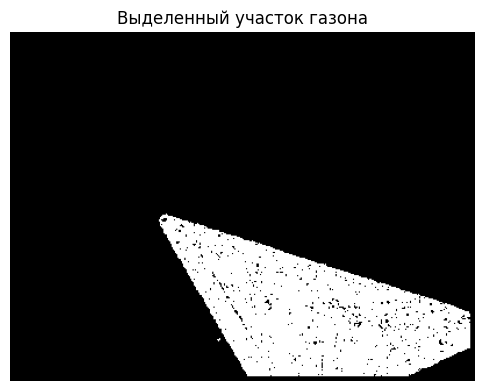

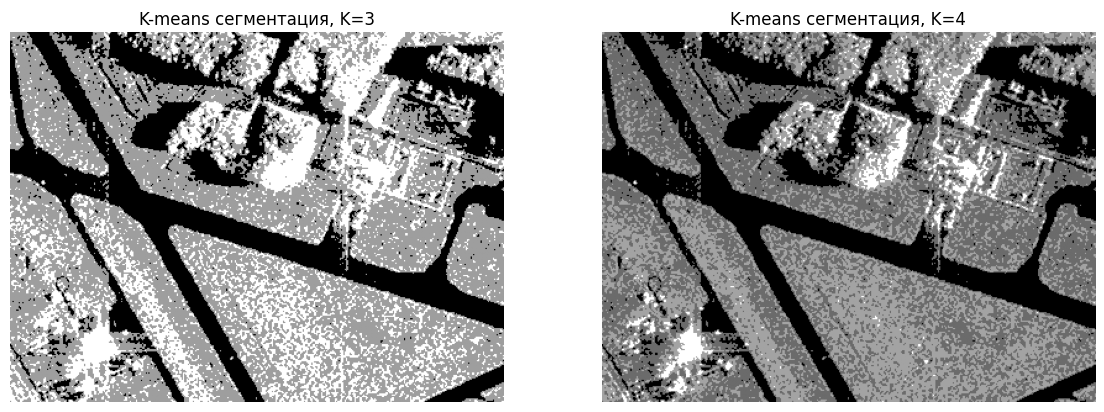

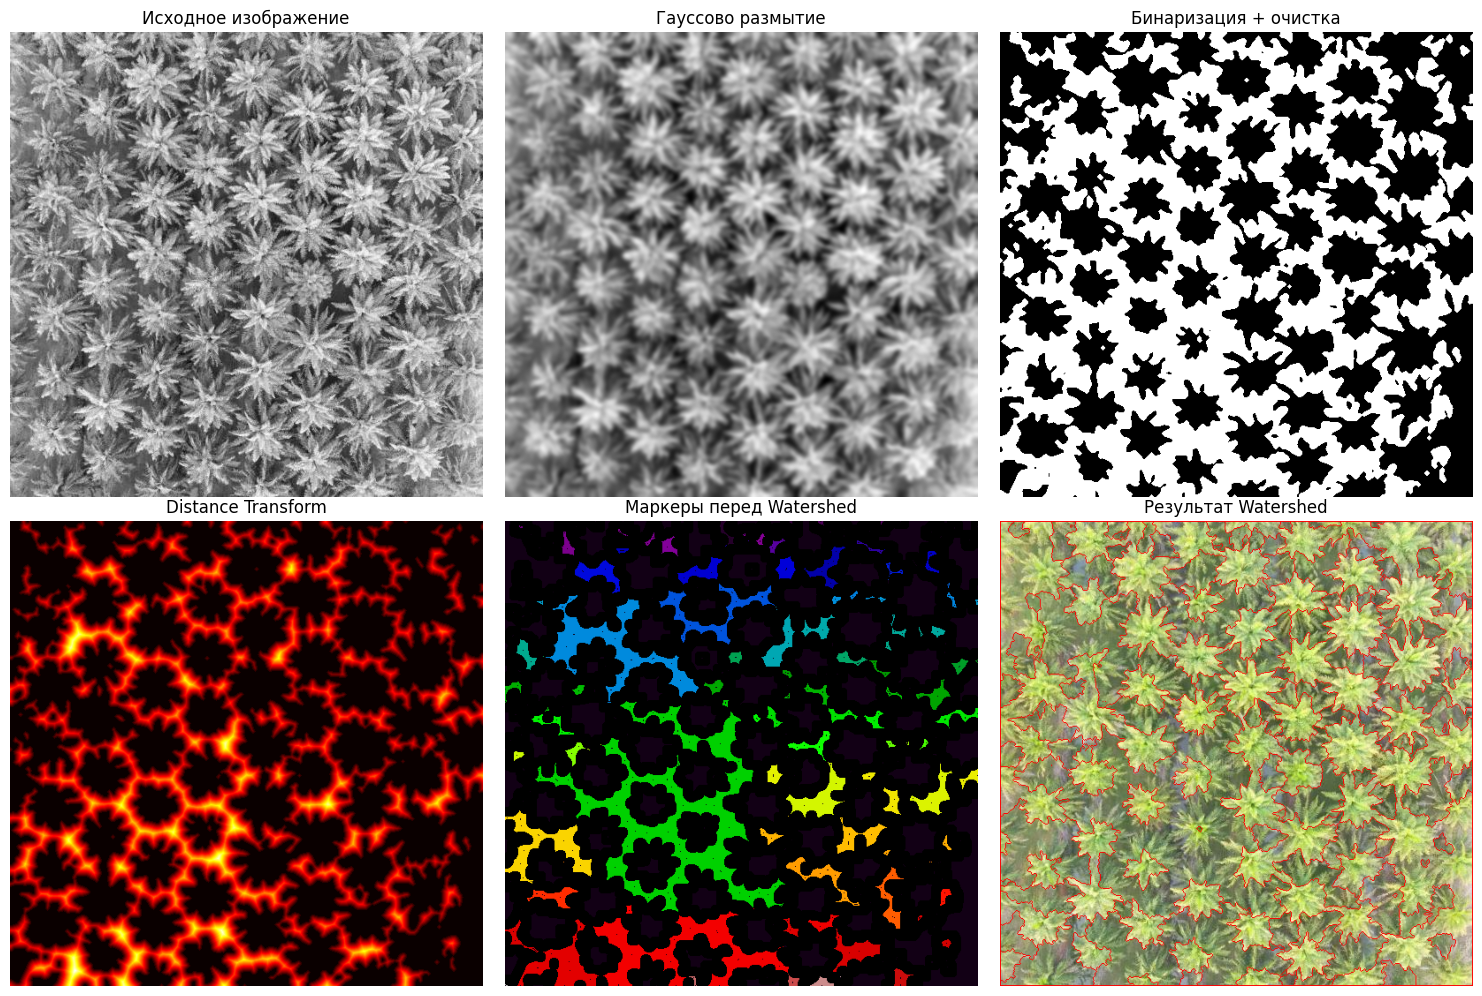

Количество объектов: 117


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage


def mean_similarity(gray, current_mask, candidate, threshold):
    region_pixels = gray[current_mask == 1]
    mean_intensity = np.mean(region_pixels)
    return abs(mean_intensity - gray[candidate]) <= threshold

def grow_area(gray, start_point, similarity_func, radius, threshold):
    region_mask = np.zeros(gray.shape, dtype=np.uint8)
    region_mask[start_point] = 1
    pixels_added = True

    while pixels_added:
        pixels_added = False
        temp_mask = np.zeros_like(region_mask)
        for x in range(radius, gray.shape[0] - radius):
            for y in range(radius, gray.shape[1] - radius):
                if region_mask[x, y] == 0:
                    neighborhood = region_mask[x-radius:x+radius, y-radius:y+radius]
                    if neighborhood.sum() > 0 and similarity_func(gray, region_mask, (x, y), threshold):
                        temp_mask[x, y] = 1
                        pixels_added = True
        region_mask |= temp_mask
    return region_mask * 255

# Загружаем изображение газона
src_img = cv2.imread("sar_1.jpg")
gray_img = cv2.cvtColor(src_img, cv2.COLOR_BGR2GRAY)

seed = (250, 250)
neighborhood_radius = 4
similarity_threshold = 18

lawn_mask = grow_area(gray_img, seed, mean_similarity, neighborhood_radius, similarity_threshold)

plt.figure(figsize=(6, 6))
plt.imshow(lawn_mask, cmap="gray")
plt.title("Выделенный участок газона")
plt.axis("off")
plt.show()


pixels = gray_img.reshape((-1, 1)).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

plt.figure(figsize=(14, 6))
for idx, k in enumerate([3, 4], start=1):
    _, labels, centers = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    segmented = centers[labels.flatten()].reshape(gray_img.shape).astype(np.uint8)
    plt.subplot(1, 2, idx)
    plt.imshow(segmented, cmap="gray")
    plt.title(f"K-means сегментация, K={k}")
    plt.axis("off")
plt.show()



palm_img = cv2.imread("palm_1.jpg")
gray_palm = cv2.cvtColor(palm_img, cv2.COLOR_BGR2GRAY)


blurred = cv2.GaussianBlur(gray_palm, (13, 13), 0)


_, binary_mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
binary_clean = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel, iterations=2)

dist_transform = cv2.distanceTransform(binary_clean, cv2.DIST_L2, 5)


local_peaks = ndimage.maximum_filter(dist_transform, size=12, mode='constant')


_, sure_fg = cv2.threshold(dist_transform, 0.3 * dist_transform.max(), 255, cv2.THRESH_BINARY)
sure_fg = sure_fg.astype(np.uint8)


_, markers = cv2.connectedComponents(sure_fg)
markers[dist_transform == local_peaks] = 1

# Watershed
markers_ws = cv2.watershed(palm_img, markers.astype(np.int32))
segmented_img = palm_img.copy()
segmented_img[markers_ws == -1] = [0, 0, 255]

# Визуализация всех этапов
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(gray_palm, cmap='gray')
plt.title("Исходное изображение")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(blurred, cmap='gray')
plt.title("Гауссово размытие")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(binary_clean, cmap='gray')
plt.title("Бинаризация + очистка")
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(dist_transform, cmap='hot')
plt.title("Distance Transform")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(markers, cmap='nipy_spectral')
plt.title("Маркеры перед Watershed")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(segmented_img, cv2.COLOR_BGR2RGB))
plt.title("Результат Watershed")
plt.axis('off')

plt.tight_layout()
plt.show()

# Подсчёт объектов
num_objects = len(np.unique(markers_ws)) - 1
print("Количество объектов:", num_objects)
